# Genomic origins of detected insertions
- Find secondary occurence of insertions in own genome and own plasmid
- Explore external origins of insertions in AllTheBacteria
- Connect the two analysis (origin in own genome / external AllTheBacteria origin)

In [1]:
# set working directory to project folder
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import pandas as pd

from junction_analysis.helpers import extract_biosample_ids
from junction_analysis.plotting import plot_hits_distribution, plot_event_length_distribution, plot_species_hits_bar

from junction_analysis.annotate_insertions import combine_NCBI_atb_results, combine_NCBI_atb_results_centralized, collect_hits_info_counts_with_self, combine_all_junctions_summaries, deduplicate_events
from junction_analysis.annotate_insertions import find_insertion_hits_own_genome, find_insertion_hits_in_plasmids

## Find secondary occurence of insertions in own genome and own plasmid

In [ ]:
# set rerun_minimap to True if you want to rerun the search
self_hits = find_insertion_hits_own_genome(genome_root = "../results/genome_fastas", insertions_seq_dir=f"../results/atb_lookup/insertions", rerun_minimap=False)
self_hits.to_csv("../results/atb_lookup/insertions/self_hits_chromosome.csv", index = False)

# 17 min

In [ ]:
# set rerun_minimap to True if you want to rerun the search
plasmid_insertions_df = find_insertion_hits_in_plasmids(plasmid_fasta_root="../results/plasmid_fastas", insertions_seq_dir=f"../results/atb_lookup/insertions", rerun_minimap=False)
plasmid_insertions_df.to_csv("../results/atb_lookup/insertions/self_hits_plasmids.csv", index=False)
# 10min

In [2]:
# pre-check that there are no insertions that were never found that are longer than 200 bp, no entries should be shown

self_hits = pd.read_csv("../results/atb_lookup/insertions/self_hits_chromosome.csv")
self_hits[(self_hits['hits_in_genome'] == 0) & (self_hits['insertion_length'] > 200)].sort_values("insertion_length", ascending=False)

,junction_name,consensus,genome_name,insertion_path,insertion_length,segment,hits_in_genome


In [2]:
# only include insertions longer than 200bp, also subtracts -1 because we only count additional occurences
length_threshold = 200

# self hits contains the correct number of non-deduplicated insertions defined by junction name, consensus, genome name and segment: 8087 (also the ones below 200bp), 6735 of them are longer than 200bp
self_hits = pd.read_csv("../results/atb_lookup/insertions/self_hits_chromosome.csv")
self_hits = self_hits[self_hits["insertion_length"] > length_threshold]
self_hits['hits_in_genome'] = self_hits["hits_in_genome"] - 1 # we are looking for additional hits in addition to the sequence itself

# plasmid summary df doesnt have a row for events that belong to genomes that don't have plasmids
plasmid_summary_df = pd.read_csv("../results/atb_lookup/insertions/self_hits_plasmids.csv")
plasmid_summary_df = plasmid_summary_df[plasmid_summary_df["insertion_length"] > length_threshold]
plasmid_summary_df = plasmid_summary_df.groupby(["junction_name","consensus", "isolate_name", "segment"])["hits_in_plasmid"].sum().reset_index()
self_hits = self_hits.merge(
    plasmid_summary_df,
    left_on=["junction_name","consensus", "genome_name", "segment"],
    right_on=["junction_name","consensus", "isolate_name", "segment"],
    how="left"
).drop(columns=['isolate_name'])
self_hits["hits_in_plasmid"] = self_hits["hits_in_plasmid"].fillna(0)

summaries = combine_all_junctions_summaries("../results/atb_lookup", save_df=False)

self_hits['consensus'] = self_hits['consensus'].str.replace('consensus', 'consensus_', regex=False)                                                                                                           

self_hits_merged = summaries['insertions'].merge(                                                                                                                                                                   
      self_hits.rename(columns={"segment": "insertion"}),                                                                                                                                                     
      on=["junction_name", "consensus", "genome_name", "insertion"],                                                                                                                                        
      how="inner"  
  )
self_hits_merged
self_hits_merged.to_csv("../results/atb_lookup/insertions/self_hits_combined.csv", index=False)

self_hits_deduplicated_df = deduplicate_events({"insertions": self_hits_merged})
self_hits_deduplicated_df['self_hits'] = self_hits_deduplicated_df['hits_in_genome'] + self_hits_deduplicated_df['hits_in_plasmid']


#insertions_df.sort_values(['consensus','insertion_path'])

In [38]:
print(f"{len(self_hits_deduplicated_df[(self_hits_deduplicated_df['hits_in_genome'] == 0) & (self_hits_deduplicated_df['hits_in_plasmid'] == 0)])} are neither found in plasmid or additionally in their own chromosome: {len(self_hits_deduplicated_df[(self_hits_deduplicated_df['hits_in_genome'] == 0) & (self_hits_deduplicated_df['hits_in_plasmid'] == 0)]) / len(self_hits_deduplicated_df) * 100} %")
print(f"{len(self_hits_deduplicated_df[(self_hits_deduplicated_df['hits_in_genome'] > 0)])} are additionally found in the chromosome: {len(self_hits_deduplicated_df[self_hits_deduplicated_df['hits_in_genome'] > 0]) / len(self_hits_deduplicated_df) * 100} %")
print(f"{len(self_hits_deduplicated_df[(self_hits_deduplicated_df['hits_in_genome'] == 0) & (self_hits_deduplicated_df['hits_in_plasmid'] > 0)])} are only found on plasmids: {len(self_hits_deduplicated_df[(self_hits_deduplicated_df['hits_in_genome'] == 0) & (self_hits_deduplicated_df['hits_in_plasmid'] > 0)]) / len(self_hits_deduplicated_df) * 100} %")

print()
print(f"{len(self_hits_deduplicated_df[(self_hits_deduplicated_df['hits_in_plasmid'] > 0) | (self_hits_deduplicated_df['hits_in_genome'] > 0)]) / len(self_hits_deduplicated_df) * 100} % of insertions have a secondary origin within their own genome or plasmid. Count: {len(self_hits_deduplicated_df[(self_hits_deduplicated_df['hits_in_plasmid'] > 0) | (self_hits_deduplicated_df['hits_in_genome'] > 0)])}")
print(f"{len(self_hits_deduplicated_df[(self_hits_deduplicated_df['hits_in_plasmid'] > 0) & (self_hits_deduplicated_df['hits_in_genome'] > 0)]) / len(self_hits_deduplicated_df)* 100} % of insertions have a secondary origin within both their own genome and plasmid. Count: {len(self_hits_deduplicated_df[(self_hits_deduplicated_df['hits_in_plasmid'] > 0) & (self_hits_deduplicated_df['hits_in_genome'] > 0)])}")

740 are neither found in plasmid or additionally in their own chromosome: 41.92634560906516 %
959 are additionally found in the chromosome: 54.3342776203966 %
66 are only found on plasmids: 3.7393767705382435 %

58.07365439093485 % of insertions have a secondary origin within their own genome or plasmid. Count: 1025
31.671388101983 % of insertions have a secondary origin within both their own genome and plasmid. Count: 559


In [43]:
self_hits_deduplicated_df[self_hits_deduplicated_df['hits_in_plasmid']==0]

,event_type,junction_name,path,ctx,consensus,insertion,fasta_path,length,strand,start_pos,end_pos,insertion_path,insertion_length,hits_in_genome,hits_in_plasmid,self_hits
0,insertion,ADIVNXMSJF_r__CGRLRHSCCE_f,[10467811667185626553|+|],12675429639006275041,consensus_1,segment_0,../results/atb_lookup/insertions/ADIVNXMSJF_r_...,10981,+,4283,15264,[10467811667185626553|+|],10981,0,0,0
1,insertion,ADOVFNSINA_f__ECOWCWQMQJ_f,[2885183895822662185|+|],12863862502596669040,consensus_1,segment_0,../results/atb_lookup/insertions/ADOVFNSINA_f_...,777,+,7189,7966,[2885183895822662185|+|],777,5,0,5
2,insertion,ADOVFNSINA_r__CAPUVXKIHV_r,[6114133947861579624|+|],6295978535415985145,consensus_1,segment_0,../results/atb_lookup/insertions/ADOVFNSINA_r_...,765,+,7190,7955,[6114133947861579624|+|],765,8,0,8
8,insertion,AFFODHUCNW_r__VRDEBAMMSO_r,[13690498838976304279|+|],18134582529277137450,consensus_1,segment_0,../results/atb_lookup/insertions/AFFODHUCNW_r_...,38347,+,6226,44573,[13690498838976304279|+|],38347,0,0,0
9,insertion,AFFODHUCNW_r__VRDEBAMMSO_r,[15161573651151395308|+|],4011715611649092347,consensus_1,segment_0,../results/atb_lookup/insertions/AFFODHUCNW_r_...,11921,+,11446,23368,[15161573651151395308|+|],11921,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1758,insertion,XXVMWZCEKI_r__YUOECYBHUS_r,[9391285909405162019|+|],10605139617336915684,consensus_3,segment_1,../results/atb_lookup/insertions/XXVMWZCEKI_r_...,877,+,104943,105820,[9391285909405162019|+|],877,1,0,1
1759,insertion,XXVMWZCEKI_r__YUOECYBHUS_r,[9474894503673110699|+|]_[3973231311631193246|...,15908320088543975006,consensus_3,segment_0,../results/atb_lookup/insertions/XXVMWZCEKI_r_...,904,+,15881,16785,[9474894503673110699|+|]_[3973231311631193246|...,904,0,0,0
1760,insertion,XXVQEZNBQB_f__YMBQLXNBIS_f,[7798500702088635138|+|],7460938438515399510,consensus_2,segment_0,../results/atb_lookup/insertions/XXVQEZNBQB_f_...,1309,+,7938,9247,[7798500702088635138|+|],1309,5,0,5
1762,insertion,YUOECYBHUS_f__ZTHKZYHPIX_f,[2624032834068938794|+|]_[1528420688200569391|...,5120184519711206319,consensus_1,segment_0,../results/atb_lookup/insertions/YUOECYBHUS_f_...,120075,+,60231,180320,[2624032834068938794|+|]_[1528420688200569391|...,120075,0,0,0


Saved figure to ../figures/n_hits_chromosome_plasmid_seperate.pdf
Saved figure to ../figures/n_hits_chromosome_plasmid.pdf


(<Figure size 700x400 with 1 Axes>,
 <Axes: xlabel='n. hits in chromosome or plasmids', ylabel='Count'>)

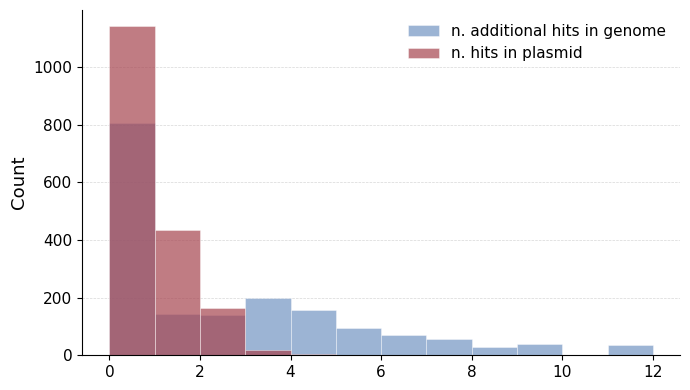

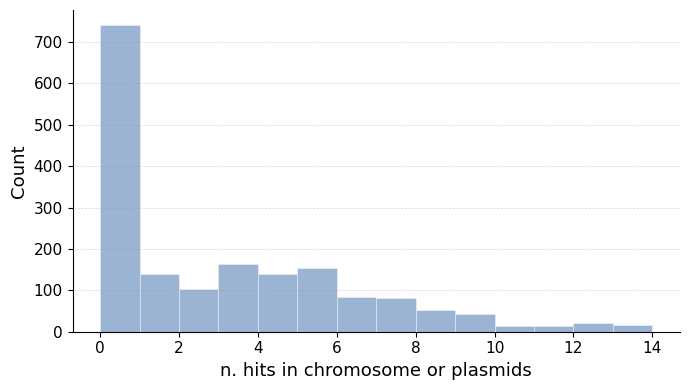

In [40]:
plot_hits_distribution(self_hits_deduplicated_df, ["hits_in_genome","hits_in_plasmid"], bin_width = 1, log_x=False, log_y = False, cumulative=False, legend_labels=["n. additional hits in genome", "n. hits in plasmid"], figsize=(7,4), two_colors=True, stacked= False, save_path="../figures/n_hits_chromosome_plasmid_seperate.pdf") 
plot_hits_distribution(self_hits_deduplicated_df, ["self_hits"], bin_width = 1, log_x=False, log_y = False, cumulative=False, xlabel = "n. hits in chromosome or plasmids", figsize=(7,4), two_colors=True, stacked= False, save_path="../figures/n_hits_chromosome_plasmid.pdf") 

## Explore external origins of insertions
Looking up origins of all insertions in AllTheBacteria

### Look up junctions in ATB - 1 junction

upload all fastas: ```scp -r /Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/results/atb_lookup/insertions/CIRMBUYJFK_f__CWCCKOQCWZ_r becker0010@transfer12.scicore.unibas.ch:/scicore/home/neher/GROUP/data/2025_all_the_bacteria/lexicmap_index/queries/```
or 
```
rsync -av \
  --include='*/' \
  --include='*.fasta' \
  --exclude='*' \
  /Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/results/atb_lookup/insertions/CIRMBUYJFK_f__CWCCKOQCWZ_r/ \
  becker0010@transfer12.scicore.unibas.ch:/scicore/home/neher/GROUP/data/2025_all_the_bacteria/lexicmap_index/queries/CIRMBUYJFK_f__CWCCKOQCWZ_r/
```

run:  `bash run_all_lexicmap.sh ./queries/CIRMBUYJFK_f__CWCCKOQCWZ_r` on cluster to submit single jobs, can only be done for one junction

this now automatically creates id files

run NCBI lookup: ```sbatch collect_ids_and_fetch.sh ./queries/CIRMBUYJFK_f__CWCCKOQCWZ_r```

download results: 
```
rsync -av --include="*/" \
--include="*.lexicmap.tsv" \
--include="*ncbi_results.tsv" \
--exclude="*" \
becker0010@transfer12.scicore.unibas.ch:/scicore/home/neher/GROUP/data/2025_all_the_bacteria/lexicmap_index/queries/CIRMBUYJFK_f__CWCCKOQCWZ_r/ \
/Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/results/atb_lookup/insertions/CIRMBUYJFK_f__CWCCKOQCWZ_r/
```

combine NCBI lookup with lexicmap hit dataframes:
run in notebook `combine_NCBI_atb_results(parent_dir="../results/atb_lookup/insertions/CIRMBUYJFK_f__CWCCKOQCWZ_r")`


### Look up junctions in AllTheBacteria - all junctions

upload all fastas: 
```
rsync -av \
  --include='*/' \
  --include='*.fasta' \
  --exclude='*' \
  /Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/results/atb_lookup/insertions/ \
  becker0010@transfer12.scicore.unibas.ch:/scicore/home/neher/GROUP/data/2025_all_the_bacteria/lexicmap_index/queries/
```

run array job for many files `bash run_all_lexicmap_array.sh ./queries/` which then runs run_all_lexicmap_array.sh
rerun timeouted jobs, now with 60 min timelimit: `bash rerun_timeout_lexicmap.sh ./logs`

ncbi lookup on all junctions: `bash collect_and_fetch_array.sh ./queries/` (can take like 5 min to load all ids, I had 454831 unique ids) and then `bash merge_biosample_results.sh ./queries` to merge

download results: 
```
rsync -av --include="*/" \
--include="*.lexicmap.tsv" \
--include="*ncbi_results.tsv" \
--exclude="*" \
becker0010@transfer12.scicore.unibas.ch:/scicore/home/neher/GROUP/data/2025_all_the_bacteria/lexicmap_index/queries/ \
/Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/results/atb_lookup/insertions/
```
final ncbi lookups are in `results/atb_lookup/insertions/all_ncbi_results.tsv`

run in notebook: `combine_NCBI_atb_results_centralized(parent_dir= "../results/atb_lookup/insertions")` to combine results (takes 12 min)


In [ ]:
# hits within their own genome or plasmids are not foreign and should be excluded
st131_sam_df = extract_biosample_ids("../data/gbk", "../data/plasmids")

hits_df = collect_hits_info_counts_with_self(                                                                                                                                                             
      "../results/atb_lookup/insertions",                                                                                                                                        
      st131_sam_df,
      min_pident=100.0                                                                                                                                                                                    
  )
hits_df['consensus'] = hits_df['consensus'].str.replace('consensus', 'consensus_', regex=False)   
hits_df.to_csv("../results/atb_lookup/insertions/lexicmap_hits_summary_100.csv", index = False)

# 1.5 min

In [ ]:
length_threshold = 200

summaries = combine_all_junctions_summaries("../results/atb_lookup", save_df=False)
summaries['insertions'] = summaries['insertions'][summaries['insertions']['length'] > length_threshold]
hits_df = pd.read_csv("../results/atb_lookup/insertions/lexicmap_hits_summary_100.csv")


hits_merged = summaries['insertions'].merge(                                                                                                                                                                   
      hits_df.rename(columns={"segment": "insertion"}),                                                                                                                                                     
      on=["junction_name", "consensus", "genome_name", "insertion"],                                                                                                                                        
      how="left"  
  )

# in case of one lexicmap lookup not working and no files beeing found (happens once for GPKQYOCEJI_r__NKVSUZGURN_f  consensus_1  NZ_AP026794.1  segment_2, try to rerun)
num_cols = hits_merged.select_dtypes(include=["number"]).columns                                                                                                                                                                            
num_cols = num_cols.difference(["ctx"])                                                                                                                                                                                                     
hits_merged[num_cols] = hits_merged[num_cols].fillna(0)
# because ctx are long integers they get reread from csv with small integer mismatches, so we convert them to string to avoid that (then also df to compare to have to be converted to string)
hits_merged["ctx"] = hits_merged["ctx"].astype(str)   

hits_merged["majority_organism"] = hits_merged["majority_organism"].where(
    hits_merged["majority_organism"].notna(), None
)

hits_merged["file_path"] = hits_merged["file_path"].where(
    hits_merged["file_path"].notna(), None
)

hits_deduplicated_df = deduplicate_events({"insertions": hits_merged})
hits_deduplicated_df.to_csv("../results/atb_lookup/insertions/lexicmap_hits_deduplicated.csv", index = False)
# 30s

In [2]:
# alternatively run this
hits_deduplicated_df = pd.read_csv("../results/atb_lookup/insertions/lexicmap_hits_deduplicated.csv")

In [3]:
# as expected not all hits are found in their own chromosome because the all the bacteria database not necessarily contains all our genomes
hits_deduplicated_df.n_hits_own_chromosome.value_counts()

n_hits_own_chromosome
0    1658
1     107
Name: count, dtype: int64

In [4]:
# and all plasmids
hits_deduplicated_df.n_hits_own_plasmid.value_counts()

n_hits_own_plasmid
0    1765
Name: count, dtype: int64

In [5]:
print(f"{len(hits_deduplicated_df[hits_deduplicated_df['n_hits_external'] == 0])} insertions have no 100% identity external matches. Percentage: {len(hits_deduplicated_df[hits_deduplicated_df['n_hits_external'] == 0]) / len(hits_deduplicated_df) * 100} %")

690 insertions have no 100% identity external matches. Percentage: 39.09348441926346 %


Saved figure to ../figures/n_external_hits.pdf


(<Figure size 700x400 with 1 Axes>, <Axes: ylabel='Count'>)

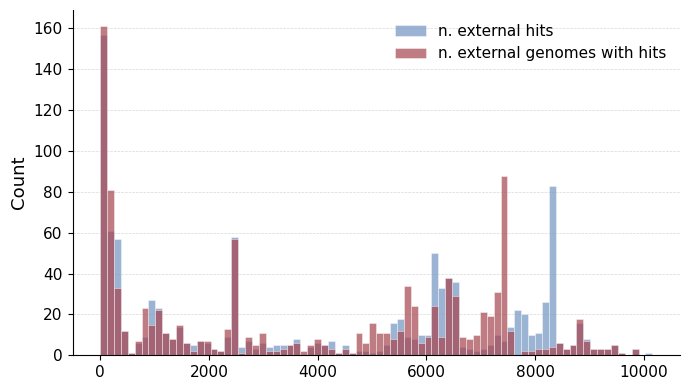

In [ ]:
# just say how many have 0 external matches
plot_hits_distribution(hits_deduplicated_df[hits_deduplicated_df['n_hits_external']>0], ["n_hits_external", "n_genomes_external"], log_x=False, log_y = False, cumulative=False, bins = 80, legend_labels=["n. external hits", "n. external genomes with hits"], figsize=(7,4), two_colors=True, save_path="../figures/n_external_hits.pdf") 

Investigate how often each species was found. Note that ST131 is counted independently of the species counts and is a subset of the E. coli hits

In [3]:
species_cols = [c for c in hits_deduplicated_df.columns if c.startswith("n_hits_") and c not in
                  {"n_hits_own_chromosome", "n_hits_own_plasmid", "n_hits_other_chromosome",
                   "n_hits_other_plasmid", "n_hits_external"}]

species_totals = hits_deduplicated_df[species_cols].sum().reset_index()
species_totals.columns = ["species", "n_hits"]
species_totals["species"] = species_totals["species"].str.replace("n_hits_", "").str.replace("_", " ")
species_totals = species_totals.sort_values("n_hits", ascending=False).reset_index(drop=True)
print(len(species_totals))
species_totals.head(20)

275


,species,n_hits
0,Escherichia coli,3386346
1,Salmonella enterica,423445
2,Shigella flexneri,212594
3,Klebsiella pneumoniae,199344
4,st131,43692
5,Shigella sonnei,21883
6,Enterobacter cloacae,8856
7,bacterium,8853
8,Acinetobacter baumannii,8429
9,Acidiphilium rubrum,5786


Saved figure to ../figures/species_assignments_external_stacked.pdf


(<Figure size 700x200 with 1 Axes>,
 <Axes: title={'center': ' '}, xlabel='Total hits'>)

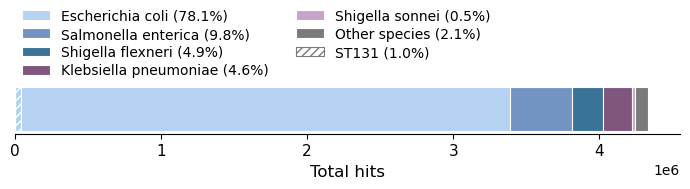

In [3]:
plot_species_hits_bar(hits_deduplicated_df.drop(columns=["n_hits_st131"]), cutoff=10000, title=" ", stacked=True, figsize=(7,2), n_st131 = hits_deduplicated_df["n_hits_st131"].sum(),  save_path="../figures/species_assignments_external_stacked.pdf")

Which majority species are hits assigned to?

In [6]:
#no majority organism assigned
print(len(hits_deduplicated_df) - hits_deduplicated_df.majority_organism.value_counts().sum())
hits_deduplicated_df.majority_organism.value_counts()

677


majority_organism
Escherichia coli           1020
Salmonella enterica          46
Klebsiella pneumoniae        11
Shigella flexneri             2
Acinetobacter baumannii       1
Shigella sonnei               1
Name: count, dtype: int64

Saved figure to ../figures/genome_hits_majority_annotation.pdf


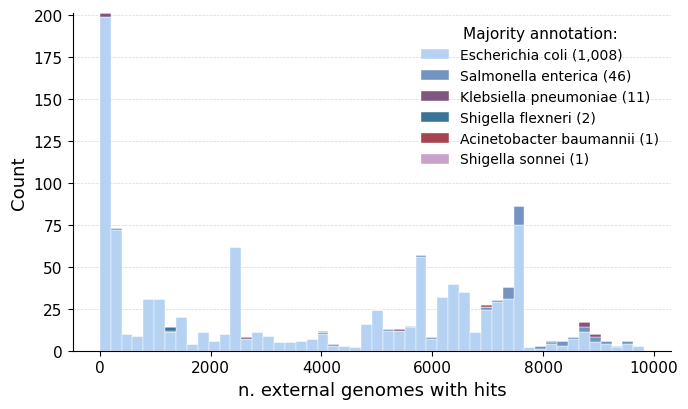

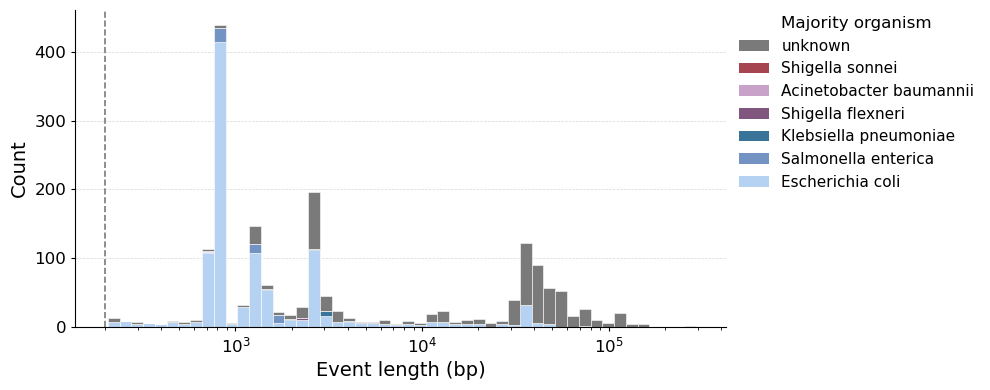

(<Figure size 1000x400 with 1 Axes>,
 <Axes: xlabel='Event length (bp)', ylabel='Count'>)

In [6]:
plot_hits_distribution(                                                                                                                                                                                   
    hits_deduplicated_df[hits_deduplicated_df['n_hits_external'] > 0],
    ["n_genomes_external"],                                                                                                                                                                               
    color_by="majority_organism",                                                                                                                                                                       
    bins=50,
    legend_title = "Majority annotation:",
    figsize=(7, 4.2),
    xlabel="n. external genomes with hits",
    save_path="../figures/genome_hits_majority_annotation.pdf"
)

plot_event_length_distribution(
      hits_deduplicated_df,
      event_types=['insertion'],
      color_by="majority_organism",
      log_x=True,
      log_y = False,
      figsize=(10,4)
  )

Now we don't limit ourselfs to the majority species:

Saved figure to ../figures/hits_with_species_counts.pdf


/Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/junction_analysis/plotting.py:2254: RuntimeWarning: invalid value encountered in divide
  heights = np.where(total_per_bin > 0, bin_totals / total_per_bin, 0) * bar_counts
/Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/junction_analysis/plotting.py:2254: RuntimeWarning: invalid value encountered in divide
  heights = np.where(total_per_bin > 0, bin_totals / total_per_bin, 0) * bar_counts


Saved figure to ../figures/species_assignments_length.pdf


(<Figure size 700x420 with 1 Axes>,
 <Axes: xlabel='Event length (bp)', ylabel='Count'>)

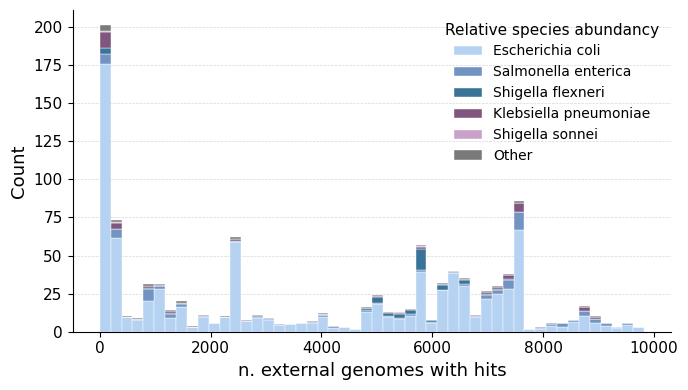

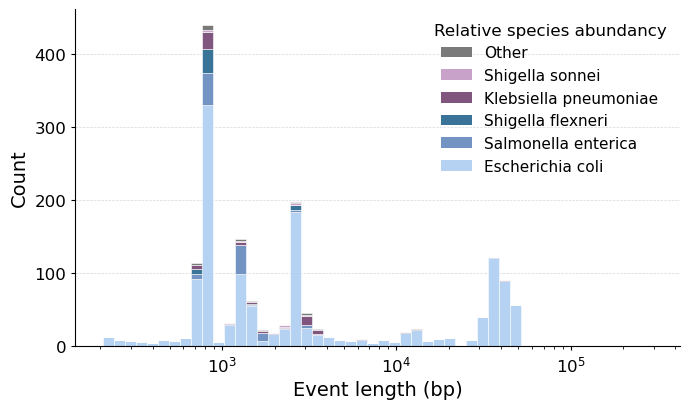

In [7]:
plot_hits_distribution(
      hits_deduplicated_df[hits_deduplicated_df['n_hits_external'] > 0],
      ["n_genomes_external"],
      color_by_species=True,
      n_species=5,
      bins=50,
      legend_title="Relative species abundancy",
      xlabel="n. external genomes with hits",
      figsize = (7,4),
      save_path="../figures/hits_with_species_counts.pdf"
  )

plot_event_length_distribution(
      hits_deduplicated_df,
      event_types=['insertion'],
      color_by="species_counts",
      n_species=5,
      log_x=True,
      log_y = False,
      figsize=(7,4.2),
      legend_title="Relative species abundancy",
      save_path="../figures/species_assignments_length.pdf",
      min_length_threshold=None
  )

## Connect the two analysis (origin in own genome / external AllTheBacteria origin)

Specifically investigate insertions with no self hits in genome or plasmid. Redo entire analysis for these hits.

In [6]:
self_hits_deduplicated_df["ctx"] = self_hits_deduplicated_df["ctx"].astype(str)

no_self_hits = self_hits_deduplicated_df[                                                                                                                                                                 
    (self_hits_deduplicated_df['hits_in_genome'] == 0) &                                                                                                                                                  
    (self_hits_deduplicated_df['hits_in_plasmid'] == 0)                                                                                                                                                   
][['junction_name', 'path', 'ctx']]                                                                                                                                                                       
                                                                                                                                                                                                        
hits_deduplicated_external_df = hits_deduplicated_df.merge(                                                                                                                                               
    no_self_hits,                                                                                                                                                                                       
    on=['junction_name', 'path', 'ctx'],
    how='inner'
)

In [7]:
# as expected not all hits are found in their own chromosome because the all the bacteria database not necessarily contains all our genomes
hits_deduplicated_external_df.n_hits_own_chromosome.value_counts()

n_hits_own_chromosome
0    708
1     32
Name: count, dtype: int64

In [47]:
print(f"{len(hits_deduplicated_external_df[hits_deduplicated_external_df['n_hits_external'] == 0])} insertions have no 100% identity external matches. Percentage: {len(hits_deduplicated_external_df[hits_deduplicated_external_df['n_hits_external'] == 0]) / len(hits_deduplicated_external_df) * 100} %")

564 insertions have no 100% identity external matches. Percentage: 76.21621621621621 %


Saved figure to ../figures/n_external_hits_no_self_hits.pdf


(<Figure size 700x400 with 1 Axes>, <Axes: ylabel='Count'>)

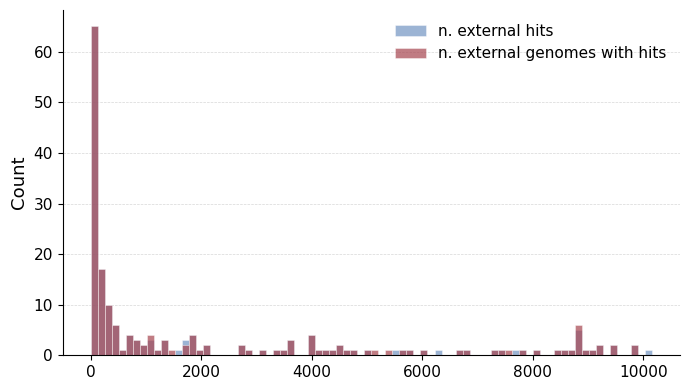

In [49]:
plot_hits_distribution(hits_deduplicated_external_df[hits_deduplicated_external_df['n_hits_external']>0], ["n_hits_external", "n_genomes_external"], log_x=False, log_y = False, cumulative=False, bins = 80, legend_labels=["n. external hits", "n. external genomes with hits"], figsize=(7,4), two_colors=True, save_path="../figures/n_external_hits_no_self_hits.pdf") 

In [50]:
species_cols = [c for c in hits_deduplicated_external_df.columns if c.startswith("n_hits_") and c not in
                  {"n_hits_own_chromosome", "n_hits_own_plasmid", "n_hits_other_chromosome",
                   "n_hits_other_plasmid", "n_hits_external"}]

species_totals = hits_deduplicated_external_df[species_cols].sum().reset_index()
species_totals.columns = ["species", "n_hits"]
species_totals["species"] = species_totals["species"].str.replace("n_hits_", "").str.replace("_", " ")
species_totals = species_totals.sort_values("n_hits", ascending=False).reset_index(drop=True)
print(len(species_totals))
species_totals.head(20)

275


,species,n_hits
0,Escherichia coli,312122
1,Klebsiella pneumoniae,22106
2,Salmonella enterica,9997
3,Shigella flexneri,5790
4,st131,4512
5,Shigella sonnei,4282
6,Enterobacter cloacae,2167
7,Enterobacter hormaechei,1599
8,bacterium,1401
9,Acinetobacter baumannii,513


In [51]:
#no majority organism assigned
print(len(hits_deduplicated_external_df) - hits_deduplicated_external_df.majority_organism.value_counts().sum())
hits_deduplicated_external_df.majority_organism.value_counts()

553


majority_organism
Escherichia coli         179
Klebsiella pneumoniae      6
Shigella sonnei            1
Salmonella enterica        1
Name: count, dtype: int64

Saved figure to ../figures/genome_hits_majority_annotation_external.pdf


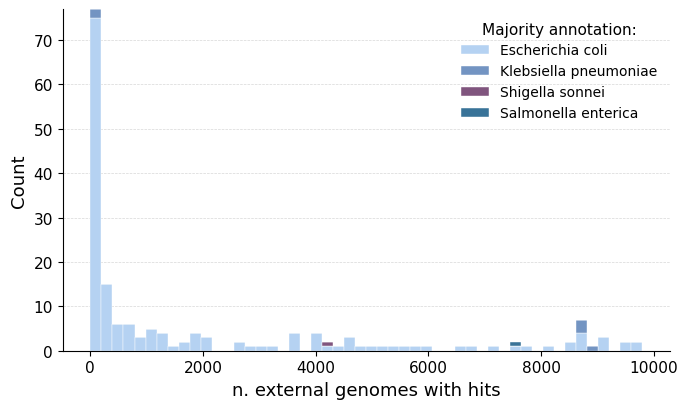

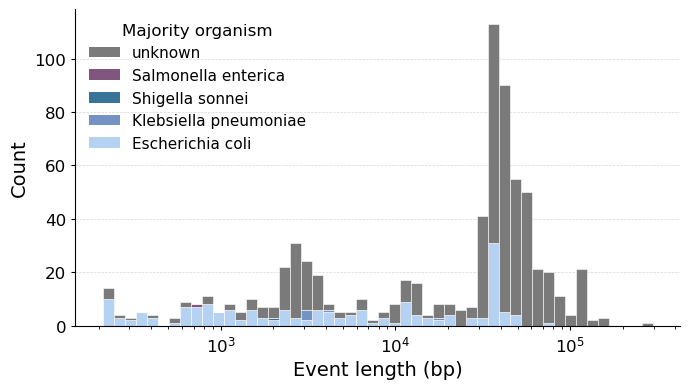

(<Figure size 700x400 with 1 Axes>,
 <Axes: xlabel='Event length (bp)', ylabel='Count'>)

In [10]:
plot_hits_distribution(                                                                                                                                                                                   
    hits_deduplicated_external_df[hits_deduplicated_external_df['n_hits_external'] > 0],
    ["n_genomes_external"],                                                                                                                                                                               
    color_by="majority_organism",                                                                                                                                                                       
    bins=50,
    legend_title = "Majority annotation:",
    figsize=(7, 4.2),
    xlabel="n. external genomes with hits",
    save_path="../figures/genome_hits_majority_annotation_external.pdf"
)

plot_event_length_distribution(
      hits_deduplicated_external_df,
      event_types=['insertion'],
      color_by="majority_organism",
      min_length_threshold=None,
      log_x=True,
      log_y = False,
      legend_loc="upper left",
      figsize=(7,4)
  )

/Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/junction_analysis/plotting.py:4650: RuntimeWarning: invalid value encountered in divide
  rel = np.where(total_species_per_bin > 0, bin_totals / total_species_per_bin, 0)
/Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/junction_analysis/plotting.py:4650: RuntimeWarning: invalid value encountered in divide
  rel = np.where(total_species_per_bin > 0, bin_totals / total_species_per_bin, 0)
/Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/junction_analysis/plotting.py:4650: RuntimeWarning: invalid value encountered in divide
  rel = np.where(total_species_per_bin > 0, bin_totals / total_species_per_bin, 0)
/Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/junction_analysis/plotting.py:4650: RuntimeWarning: invalid value encountered in divide
  rel = np.where(total_species_per_bin > 0, bin_totals / total_species_per_bin, 0)
/Users/mariebecker/Documents/Uni/ETH/Masterarbeit/ma

Saved figure to ../figures/hits_with_species_counts_external.pdf


/Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/junction_analysis/plotting.py:2254: RuntimeWarning: invalid value encountered in divide
  heights = np.where(total_per_bin > 0, bin_totals / total_per_bin, 0) * bar_counts
/Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/junction_analysis/plotting.py:2254: RuntimeWarning: invalid value encountered in divide
  heights = np.where(total_per_bin > 0, bin_totals / total_per_bin, 0) * bar_counts


Saved figure to ../figures/species_assignments_length_external.pdf


(<Figure size 700x420 with 1 Axes>,
 <Axes: xlabel='Event length (bp)', ylabel='Count'>)

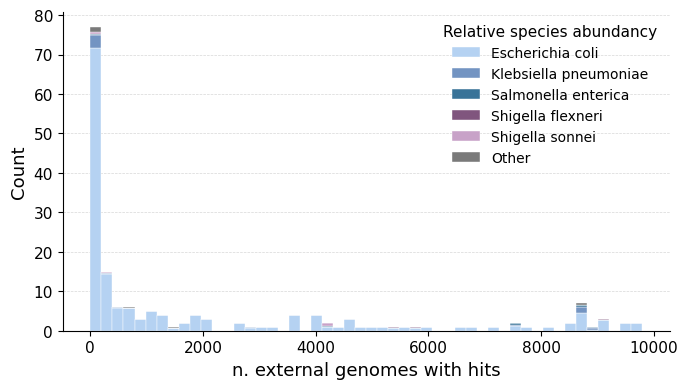

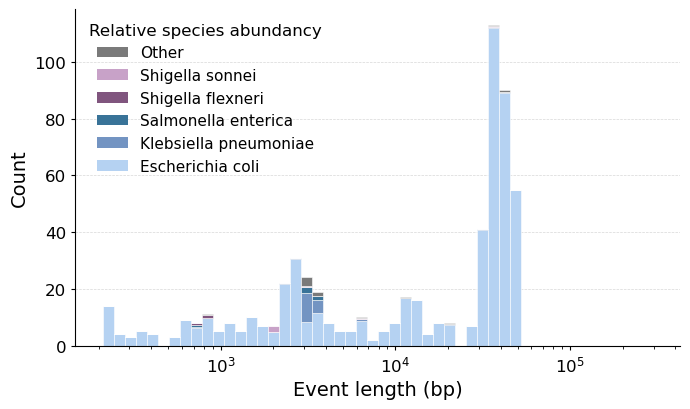

In [8]:
plot_hits_distribution(
      hits_deduplicated_external_df[hits_deduplicated_external_df['n_hits_external'] > 0],
      ["n_genomes_external"],
      color_by_species=True,
      n_species=5,
      bins=50,
      legend_title="Relative species abundancy",
      xlabel="n. external genomes with hits",
      figsize = (7,4),
      save_path="../figures/hits_with_species_counts_external.pdf"
  )

plot_event_length_distribution(
      hits_deduplicated_external_df,
      event_types=['insertion'],
      color_by="species_counts",
      n_species=5,
      log_x=True,
      log_y = False,
      figsize=(7,4.2),
      legend_title="Relative species abundancy",
      legend_loc="upper left",
      save_path="../figures/species_assignments_length_external.pdf",
      min_length_threshold=None
  )

## Detailed description of CIRMBUYJFK_f__CWCCKOQCWZ_r
Information about different insertion sequences of CIRMBUYJFK_f__CWCCKOQCWZ_r:

- 5 different versions of this block, if a block is twice in one sequence it is always the same version twice, versions can be inserted or not inserted, found between 1 and 9 times in other genomes
    - NZ_CP107151.1, blocks [6932368721519041699|-|]: majority of hits are Mycoplasma mycoides or E. coli and some others, IS1 based on annotation, same insertion in NZ_CP107162.1 and NZ_CP107122.1 blocks [6932368721519041699|-|], same hits, NZ_CP107122.1 even has same insertion a second time[6932368721519041699|+|], NZ_CP128907.1|segment_0 path[6932368721519041699|+|1708810210093552769] length760, NZ_AP022326.1|segment_0 path[6932368721519041699|+|5100696243500885373] length777, NZ_AP022326.1|segment_1 path[6932368721519041699|+|6097212296783908714] length777, NZ_CP124410.1: path[6932368721519041699|+|] IS1, Mycoplasma mycoides and E.coli and Campylobacter jejuni and some more
    - NZ_CP021454.1|segment_0 path[6932368721519041699|-|913783977968963568] length777 and NZ_CP019012.1|segment_0 path[6932368721519041699|-|10145330714100251892] length768 (only found once in genome), inverted, IS1, only 4 hits and different ones --> difference within block!
    - NZ_OX030701.1|segment_0 path[6932368721519041699|-|] length760, NZ_CP018970.1|segment_0 path[6932368721519041699|-|17115477248436968411] length767, NZ_CP023826.1|segment_0 path[6932368721519041699|-|17115477248436968411] length767, NZ_LR890693.1|segment_0 path[6932368721519041699|-|11588582069103229002] length760, NZ_CP051661.1|segment_1 path[6932368721519041699|+|10145330714100251892] length776 and segment_0 path[6932368721519041699|+|12883103544713419939] length776, NZ_CP051663.1|segment_0 path[6932368721519041699|+|7987278316461198430] length764, NZ_CP051659.1|segment_0 path[6932368721519041699|+|10145330714100251892] length760, NZ_CP018970.1|segment_0 path[6932368721519041699|-|17115477248436968411] length767, NZ_CP023826.1|segment_0 path[6932368721519041699|-|17115477248436968411] length767, NZ_CP124455.1|segment_0 path[6932368721519041699|-|15558722379768673797] length768, same hits, less hits, IS1
    - NZ_CP030337.1|segment_0 path[6932368721519041699|+|16056383497489254679] length760, Campylobacter jejuni version (?)
    - NZ_AP022044.1|segment_0 path[6932368721519041699|+|12883103544713419939] length767 and NZ_AP022044.1|segment_1 path[6932368721519041699|-|14506298656834147691] length767, new version, mostly E.coli, 25 hits

- NZ_CP103562.1: path[7844090243072536214|+|] E. coli and some single different ones, IS3, found twice in genome

- double block: all found twice (once elsewhere in genome), all at same position, just some inverted
    - NZ_CP124374.1 and NZ_CP019015.1: [16982887268023976258|-|]_[964531385716605116|-|] ISL3 (both blogs together): no hits (TODO: change parameters and rerun or run blogs seperately)
    - NZ_CP059130.1 (segment 1), NZ_AP026788.1 and NZ_AP026794.1, [964531385716605116|+|]_[16982887268023976258|+|], NZ_CP124460.1|segment_0 path[964531385716605116|+|]_[16982887268023976258|+|] length1863, NZ_CP027534.1|segment_0 path[964531385716605116|+|]_[16982887268023976258|+|] length1863, NZ_CP128947.1|segment_0 path[964531385716605116|+|]_[16982887268023976258|+|] length1863: ISL3, mostly E.coli, same hits
    - NZ_LR890693.1|segment_1 path[964531385716605116|-|]_[16982887268023976258|-|], NZ_CP010876.1|segment_0 path[964531385716605116|-|]_[16982887268023976258|-|] length1893, (order was inverted here) length1893, this one got hits now, all E.coli (why hits even though sequences don't fit)
- NZ_CP124424.1|segment_0 path[964531385716605116|+|] length1324, exist as partly insertion (only first block), less hits, E.coli and Lelliottia amnigena, ISL3, found twice


- NZ_CP021935.1, NZ_CP059130.1 (segment 0), NZ_CP107114.1 and NZ_CP107172.1 (identical), NZ_CP107114.1, NZ_CP107172, NZ_CP021179.1, NZ_CP018979.1 and NZ_CP124429.1 (inverted): 517157241956952768 IS3, 100% hits in E.coli and in other bacteria, mostly E. coli, all get the same hits, they might differ in a few bases or some bases at ends, inserted at different positions in genome, one has 3 base overhang, apart from that they are completely the same, different amount of hits in genome (between 2 and 7)

- NZ_AP026788.1 and NZ_AP026794.1: path[16556873922195442803|+|] IS1380, E. coli, Klebsiella pneumoniae, Pseudomonas aeruginosa,Salmonella enterica all frequent, many more, twice in genome and both have same hits

- NZ_CP019008.1|segment_0 path[185719230501067033|+|] length4204, NZ_CP133923.1|segment_0 path[185719230501067033|+|] length4204, NZ_CP124467.1|segment_0 path[185719230501067033|+|] length4204, NZ_CP134384.1|segment_0 path[185719230501067033|+|] length4203 (one nucleotide shorter): 200 hits that are all E. coli. all sequences identical, only once in genome


Difference between consensus 1 and consensus 2 in one big prophage according to annotations